In [1]:
import os
os.makedirs('flight_data', exist_ok=True)
print("Folder created!")

Folder created!


In [2]:
import pandas as pd
import os
import gc

folder = os.path.expanduser("~/Documents/flight_data")

# Define common columns to keep
def process_csv(filepath):
    df = pd.read_csv(filepath, low_memory=False)
    df = df.rename(columns={
        'FL_DATE': 'FlightDate',
        'OP_CARRIER': 'Airline',
        'ORIGIN': 'Origin',
        'DEST': 'Dest',
        'CRS_DEP_TIME': 'CRSDepTime',
        'DEP_TIME': 'DepTime',
        'DEP_DELAY': 'DepDelay',
        'CRS_ARR_TIME': 'CRSArrTime',
        'ARR_TIME': 'ArrTime',
        'ARR_DELAY': 'ArrDelay',
        'CANCELLED': 'Cancelled',
        'CANCELLATION_CODE': 'CancellationCode',
        'DIVERTED': 'Diverted',
        'AIR_TIME': 'AirTime',
        'DISTANCE': 'Distance',
        'CARRIER_DELAY': 'CarrierDelay',
        'WEATHER_DELAY': 'WeatherDelay',
        'NAS_DELAY': 'NASDelay',
        'SECURITY_DELAY': 'SecurityDelay',
        'LATE_AIRCRAFT_DELAY': 'LateAircraftDelay',
    })
    df['FlightDate'] = pd.to_datetime(df['FlightDate'])
    df['Year'] = df['FlightDate'].dt.year
    df['Month'] = df['FlightDate'].dt.month
    df['DayofMonth'] = df['FlightDate'].dt.day
    return df

def process_parquet(filepath):
    df = pd.read_parquet(filepath)
    df['FlightDate'] = pd.to_datetime(df['FlightDate'])
    return df

# Final common columns
COLS = ['FlightDate', 'Year', 'Month', 'DayofMonth', 'Airline',
        'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay',
        'CRSArrTime', 'ArrTime', 'ArrDelay', 'Cancelled', 'Diverted',
        'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay',
        'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

all_dfs = []

# Load CSV files 2009-2018
for year in range(2009, 2019):
    print(f"Loading {year}.csv...")
    df = process_csv(os.path.join(folder, f'{year}.csv'))
    cols = [c for c in COLS if c in df.columns]
    all_dfs.append(df[cols])
    gc.collect()

# Load Parquet files 2019-2022
for year in range(2019, 2023):
    print(f"Loading Combined_Flights_{year}.parquet...")
    df = process_parquet(os.path.join(folder, f'Combined_Flights_{year}.parquet'))
    cols = [c for c in COLS if c in df.columns]
    all_dfs.append(df[cols])
    gc.collect()

print("\nMerging all datasets...")
df_all = pd.concat(all_dfs, ignore_index=True)
print(f"✅ Complete dataset: {len(df_all):,} rows, {len(df_all.columns)} columns")
print(f"Years covered: {df_all['Year'].min()} - {df_all['Year'].max()}")

Loading 2009.csv...
Loading 2010.csv...
Loading 2011.csv...
Loading 2012.csv...
Loading 2013.csv...
Loading 2014.csv...
Loading 2015.csv...
Loading 2016.csv...
Loading 2017.csv...
Loading 2018.csv...
Loading Combined_Flights_2019.parquet...
Loading Combined_Flights_2020.parquet...
Loading Combined_Flights_2021.parquet...
Loading Combined_Flights_2022.parquet...

Merging all datasets...
✅ Complete dataset: 85,061,234 rows, 22 columns
Years covered: 2009 - 2022


In [3]:
output_path = os.path.join(folder, 'flights_2009_2022.parquet')
print("Saving unified dataset...")
df_all.to_parquet(output_path, index=False, engine='pyarrow')
size = os.path.getsize(output_path) / (1024*1024*1024)
print(f"✅ Saved: {output_path}")
print(f"   Size: {size:.2f} GB")

Saving unified dataset...
✅ Saved: /Users/riccardolangella/Documents/flight_data/flights_2009_2022.parquet
   Size: 1.05 GB


In [4]:
# Dataset overview
print("=== DATASET OVERVIEW ===")
print(f"Total rows: {len(df_all):,}")
print(f"Columns: {list(df_all.columns)}")
print(f"\nYears: {df_all['Year'].min()} - {df_all['Year'].max()}")
print(f"\nFlights per year:")
print(df_all.groupby('Year').size().to_string())
print(f"\nMissing values per column:")
print(df_all.isnull().sum().to_string())
print(f"\nDelay statistics:")
print(df_all[['DepDelay', 'ArrDelay']].describe())
print(f"\nCancellation rate: {df_all['Cancelled'].mean()*100:.2f}%")

=== DATASET OVERVIEW ===
Total rows: 85,061,234
Columns: ['FlightDate', 'Year', 'Month', 'DayofMonth', 'Airline', 'Origin', 'Dest', 'CRSDepTime', 'DepTime', 'DepDelay', 'CRSArrTime', 'ArrTime', 'ArrDelay', 'Cancelled', 'Diverted', 'AirTime', 'Distance', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

Years: 2009 - 2022

Flights per year:
Year
2009    6429338
2010    6450117
2011    6066650
2012    6096762
2013    6369482
2014    5819811
2015    5819079
2016    5617658
2017    5674621
2018    7213446
2019    8091684
2020    5022397
2021    6311871
2022    4078318

Missing values per column:
FlightDate                  0
Year                        0
Month                       0
DayofMonth                  0
Airline                     0
Origin                      0
Dest                        0
CRSDepTime                  1
DepTime               1611995
DepDelay              1617184
CRSArrTime                  2
ArrTime               1692577
ArrDelay

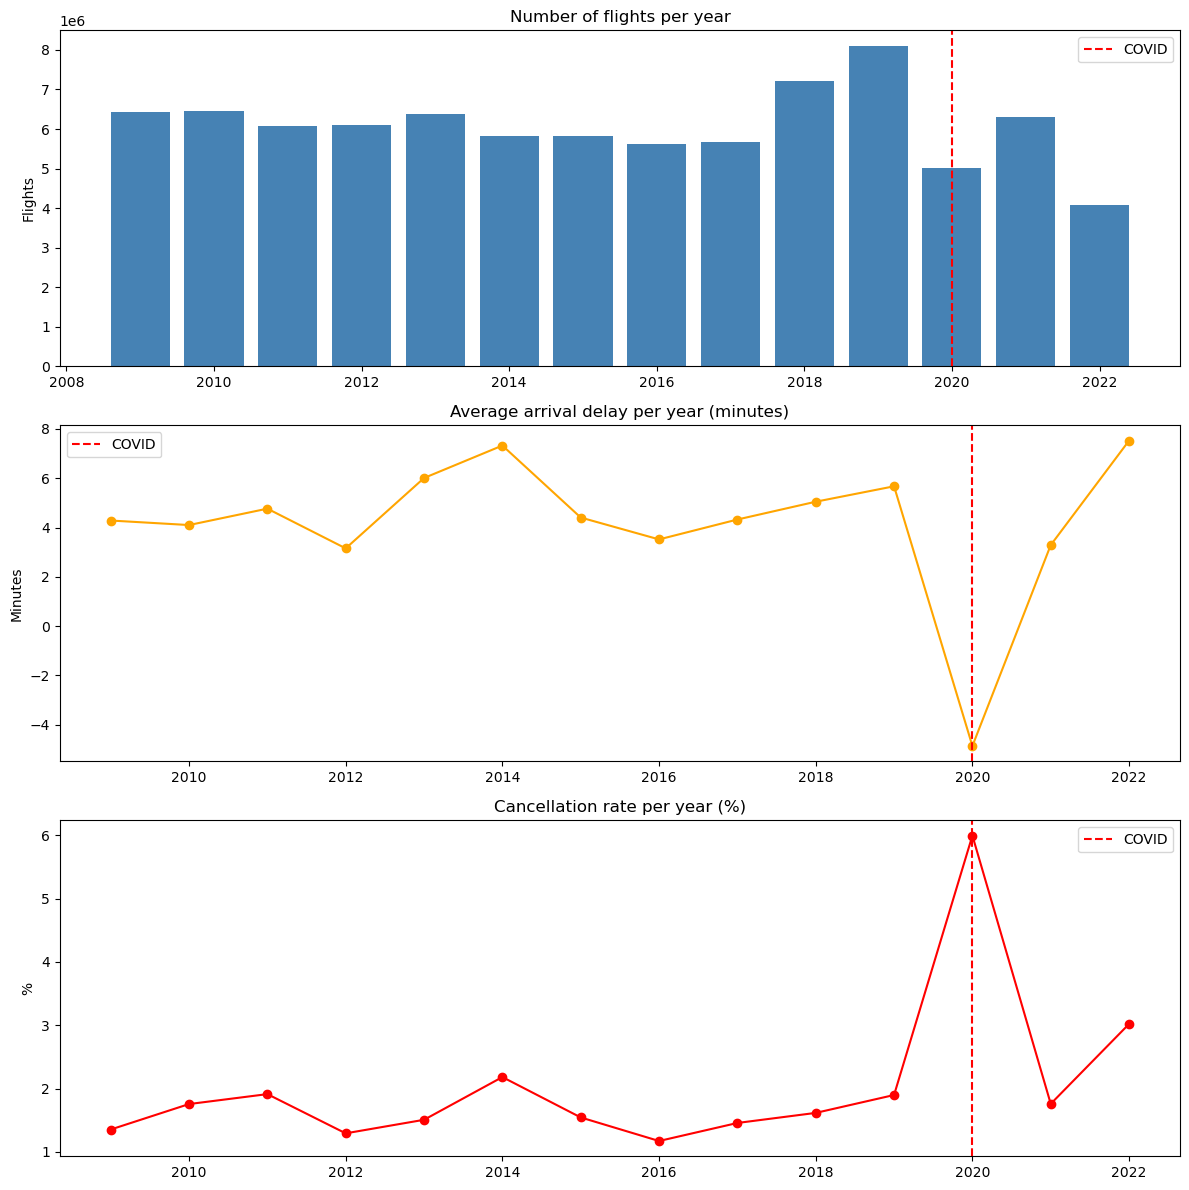

✅ Chart saved!


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# 1. Flights per year
yearly = df_all.groupby('Year').size()
axes[0].bar(yearly.index, yearly.values, color='steelblue')
axes[0].set_title('Number of flights per year')
axes[0].set_ylabel('Flights')
axes[0].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[0].legend()

# 2. Average arrival delay per year
yearly_delay = df_all.groupby('Year')['ArrDelay'].mean()
axes[1].plot(yearly_delay.index, yearly_delay.values, marker='o', color='orange')
axes[1].set_title('Average arrival delay per year (minutes)')
axes[1].set_ylabel('Minutes')
axes[1].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[1].legend()

# 3. Cancellation rate per year
yearly_cancel = df_all.groupby('Year')['Cancelled'].mean() * 100
axes[2].plot(yearly_cancel.index, yearly_cancel.values, marker='o', color='red')
axes[2].set_title('Cancellation rate per year (%)')
axes[2].set_ylabel('%')
axes[2].axvline(x=2020, color='red', linestyle='--', label='COVID')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(folder, 'overview.png'), dpi=150)
plt.show()
print("✅ Chart saved!")

In [6]:
print("Shape before cleaning:", df_all.shape)

# Remove extreme outliers (delays > 24 hours are almost certainly errors)
df_clean = df_all[
    (df_all['DepDelay'].isna()) | (df_all['DepDelay'].between(-120, 1440))
].copy()

# For delay causes, NaN means "no delay" → replace with 0
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
df_clean[delay_cols] = df_clean[delay_cols].fillna(0)

print("Shape after cleaning:", df_clean.shape)
print(f"Rows removed: {len(df_all) - len(df_clean):,}")

Shape before cleaning: (85061234, 22)
Shape after cleaning: (85060091, 22)
Rows removed: 1,143


In [7]:
# Feature engineering
df_clean['IsDelayed'] = (df_clean['ArrDelay'] > 15).astype(int)  # 1 if arrival delay > 15 min
df_clean['IsWeekend'] = df_clean['DayOfWeek'].isin([6, 7]).astype(int) if 'DayOfWeek' in df_clean.columns else 0
df_clean['DepHour'] = (df_clean['CRSDepTime'] // 100).fillna(-1).astype(int)  # departure hour
df_clean['Season'] = df_clean['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

print("New features created:")
print(f"  Delayed flights (>15 min): {df_clean['IsDelayed'].sum():,} ({df_clean['IsDelayed'].mean()*100:.1f}%)")
print(f"\nDelay rate by season:")
print(df_clean.groupby('Season')['IsDelayed'].mean().sort_values(ascending=False) * 100)
print(f"\nDelay rate by departure hour (top 5 worst):")
print(df_clean.groupby('DepHour')['IsDelayed'].mean().sort_values(ascending=False).head(5) * 100)

New features created:
  Delayed flights (>15 min): 14,732,110 (17.3%)

Delay rate by season:
Season
Summer    20.266017
Winter    18.237775
Spring    16.610624
Fall      13.838389
Name: IsDelayed, dtype: float64

Delay rate by departure hour (top 5 worst):
DepHour
-1     100.000000
 19     24.244632
 20     24.236020
 18     24.056785
 21     23.150249
Name: IsDelayed, dtype: float64


In [8]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Sample 1M rows for training
print("Creating sample for ML...")
df_sample = df_clean[df_clean['ArrDelay'].notna()].sample(n=1_000_000, random_state=42)

# Encode categorical features as numeric codes
df_sample['Airline_code'] = df_sample['Airline'].astype('category').cat.codes
df_sample['Route'] = df_sample['Origin'] + '_' + df_sample['Dest']
df_sample['Route_code'] = df_sample['Route'].astype('category').cat.codes
df_sample['Origin_code'] = df_sample['Origin'].astype('category').cat.codes
df_sample['Dest_code'] = df_sample['Dest'].astype('category').cat.codes

# Create mapping dictionaries for the Streamlit app
airline_map = dict(zip(df_sample['Airline'], df_sample['Airline_code']))
origin_map = dict(zip(df_sample['Origin'], df_sample['Origin_code']))
dest_map = dict(zip(df_sample['Dest'], df_sample['Dest_code']))
route_map = dict(zip(df_sample['Route'], df_sample['Route_code']))

print(f"Sample size: {len(df_sample):,} rows")
print(f"Airlines: {len(airline_map)}, Origins: {len(origin_map)}, Destinations: {len(dest_map)}")

Creating sample for ML...
Sample size: 1,000,000 rows
Airlines: 49, Origins: 401, Destinations: 399


In [9]:
# Compute historical delay rate per airline, route and hour
print("Computing historical features...")

# Average delay rate per airline
airline_delay = df_clean.groupby('Airline')['IsDelayed'].mean().rename('Airline_delay_rate')

# Average delay rate per route
df_clean['Route'] = df_clean['Origin'] + '_' + df_clean['Dest']
route_delay = df_clean.groupby('Route')['IsDelayed'].mean().rename('Route_delay_rate')

# Average delay rate per departure hour
hour_delay = df_clean.groupby('DepHour')['IsDelayed'].mean().rename('Hour_delay_rate')

# Average delay rate per month
month_delay = df_clean.groupby('Month')['IsDelayed'].mean().rename('Month_delay_rate')

# Merge historical features into sample
df_sample['Route'] = df_sample['Origin'] + '_' + df_sample['Dest']
df_sample = df_sample.join(airline_delay, on='Airline')
df_sample = df_sample.join(route_delay, on='Route')
df_sample = df_sample.join(hour_delay, on='DepHour')
df_sample = df_sample.join(month_delay, on='Month')

print("Historical features added:")
print(df_sample[['Airline_delay_rate', 'Route_delay_rate', 
                  'Hour_delay_rate', 'Month_delay_rate']].describe())

Computing historical features...
Historical features added:
       Airline_delay_rate  Route_delay_rate  Hour_delay_rate  Month_delay_rate
count      1000000.000000    1000000.000000   1000000.000000    1000000.000000
mean             0.173099          0.172990         0.173172          0.173153
std              0.027037          0.040272         0.052401          0.025301
min              0.079198          0.000000         0.072381          0.134066
25%              0.158810          0.146492         0.130111          0.161312
50%              0.174257          0.171249         0.178119          0.173681
75%              0.187171          0.198344         0.228482          0.201096
max              0.367707          1.000000         0.242446          0.212373


In [10]:
# Extended feature set with historical rates
features = ['Month', 'DayofMonth', 'DepHour', 'Distance', 
            'Airline_code', 'Origin_code', 'Dest_code', 'Route_code',
            'Airline_delay_rate', 'Route_delay_rate', 
            'Hour_delay_rate', 'Month_delay_rate']

X = df_sample[features].fillna(-1)
y = df_sample['IsDelayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scale = (y_train == 0).sum() / (y_train == 1).sum()

print("Training improved XGBoost...")
model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test, y_pred))

# Updated feature importance
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print("\nFeature Importance:")
print(importance.to_string(index=False))

Training improved XGBoost...

Accuracy: 62.7%

Detailed report:
              precision    recall  f1-score   support

           0       0.88      0.63      0.74    164622
           1       0.26      0.60      0.36     35378

    accuracy                           0.63    200000
   macro avg       0.57      0.62      0.55    200000
weighted avg       0.77      0.63      0.67    200000


Feature Importance:
           Feature  Importance
   Hour_delay_rate    0.353006
  Route_delay_rate    0.105565
  Month_delay_rate    0.086071
           DepHour    0.085494
Airline_delay_rate    0.071835
      Airline_code    0.051582
             Month    0.047351
        Route_code    0.044055
          Distance    0.040847
         Dest_code    0.040614
       Origin_code    0.037212
        DayofMonth    0.036369


In [11]:
import pickle

# Save the trained model and encoders
print("Saving model and encoders...")

model_data = {
    'model': model,
    'features': features,
    'airline_map': airline_map,
    'origin_map': origin_map,
    'dest_map': dest_map,
    'route_map': route_map,
    'airline_delay': airline_delay,
    'route_delay': route_delay,
    'hour_delay': hour_delay,
    'month_delay': month_delay,
}

with open(os.path.join(folder, 'flight_delay_model.pkl'), 'wb') as f:
    pickle.dump(model_data, f)

size = os.path.getsize(os.path.join(folder, 'flight_delay_model.pkl')) / (1024*1024)
print(f"✅ Model saved! Size: {size:.1f} MB")


Saving model and encoders...
✅ Model saved! Size: 3.1 MB


In [12]:
# Build balanced sample with cancellations
print("Building balanced sample for cancellation model...")

# Take all cancelled flights
cancelled = df_clean[df_clean['Cancelled'] == 1]
not_cancelled = df_clean[df_clean['Cancelled'] == 0].sample(n=len(cancelled)*4, random_state=42)

df_cancel_sample = pd.concat([cancelled, not_cancelled]).sample(frac=1, random_state=42)
print(f"Cancelled flights: {len(cancelled):,}")
print(f"Not cancelled flights: {len(not_cancelled):,}")
print(f"Total sample: {len(df_cancel_sample):,}")

# Add route and historical features
df_cancel_sample['Route'] = df_cancel_sample['Origin'] + '_' + df_cancel_sample['Dest']
df_cancel_sample['Airline_code'] = df_cancel_sample['Airline'].astype('category').cat.codes
df_cancel_sample['Route_code'] = df_cancel_sample['Route'].astype('category').cat.codes
df_cancel_sample['Origin_code'] = df_cancel_sample['Origin'].astype('category').cat.codes
df_cancel_sample['Dest_code'] = df_cancel_sample['Dest'].astype('category').cat.codes
df_cancel_sample = df_cancel_sample.join(airline_delay, on='Airline')
df_cancel_sample = df_cancel_sample.join(route_delay, on='Route')
df_cancel_sample = df_cancel_sample.join(hour_delay, on='DepHour')
df_cancel_sample = df_cancel_sample.join(month_delay, on='Month')

X_cancel = df_cancel_sample[features].fillna(-1)
y_cancel = df_cancel_sample['Cancelled']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancel, y_cancel, test_size=0.2, random_state=42)

print("\nTraining cancellation model...")
model_cancel = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model_cancel.fit(X_train_c, y_train_c)

y_pred_c = model_cancel.predict(X_test_c)
print(f"\nAccuracy: {accuracy_score(y_test_c, y_pred_c)*100:.1f}%")
print("\nDetailed report:")
print(classification_report(y_test_c, y_pred_c))


Building balanced sample for cancellation model...
Cancelled flights: 1,662,096
Not cancelled flights: 6,648,384
Total sample: 8,310,480

Training cancellation model...

Accuracy: 82.4%

Detailed report:
              precision    recall  f1-score   support

         0.0       0.84      0.97      0.90   1330153
         1.0       0.66      0.24      0.35    331943

    accuracy                           0.82   1662096
   macro avg       0.75      0.61      0.63   1662096
weighted avg       0.80      0.82      0.79   1662096



In [13]:
# Save cancellation model
model_data['model_cancel'] = model_cancel

with open(os.path.join(folder, 'flight_delay_model.pkl'), 'wb') as f:
    pickle.dump(model_data, f)

print("✅ Cancellation model saved!")

✅ Cancellation model saved!
